In [1]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.siac_fourier import siac_filter_odl

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom
)


/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


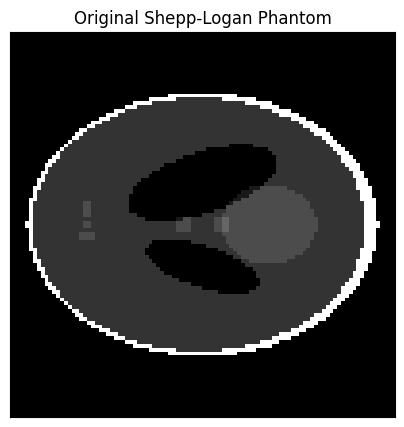

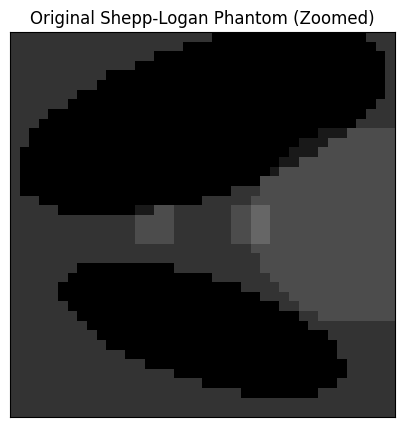

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Original Shepp-Logan Phantom (Zoomed)'}>)

In [3]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)

plot_img(img=phantom, title="Original Shepp-Logan Phantom")
plot_img_zoom(img=phantom, title="Original Shepp-Logan Phantom (Zoomed)")

In [4]:
import odl, inspect
import odl.tomo.analytic.filtered_back_projection as fbpmod
print(odl.__version__)
print(inspect.getsource(fbpmod._fbp_filter))

0.8.3
def _fbp_filter(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_ty

In [5]:
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_type='Hann',
    ...                    frequency_scaling=0.8)
    """
    # filter_type, filter_type_in = str(filter_type).lower(), filter_type
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt


# Patch
fbpmod._fbp_filter = _fbp_filter_patched


In [6]:
### Compute the FBP with the ramp filter only and Hann window

# Create a Noisy phantom using the FBP
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)
fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")

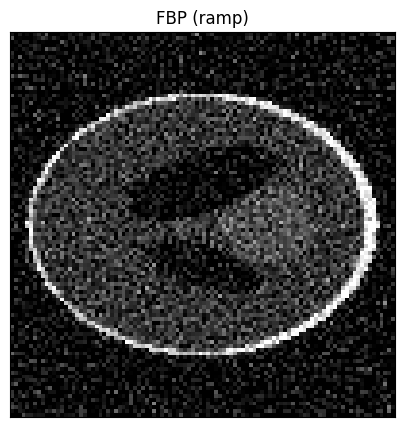

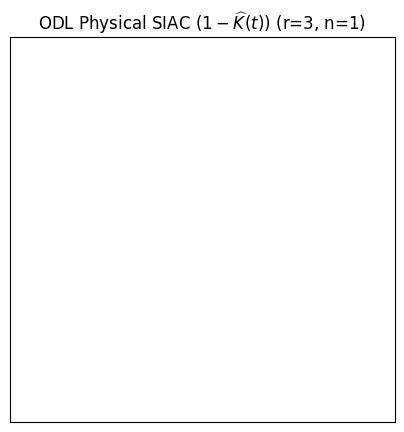

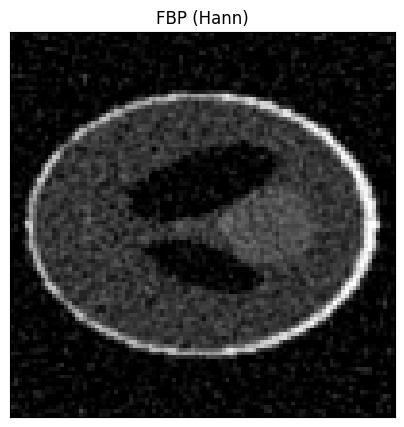

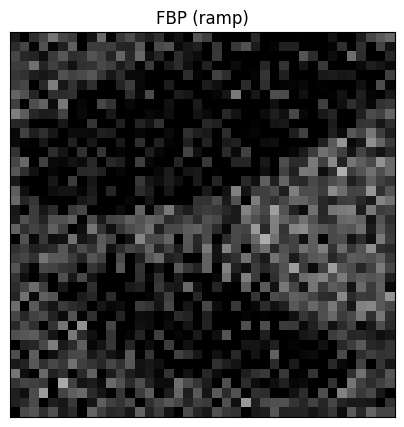

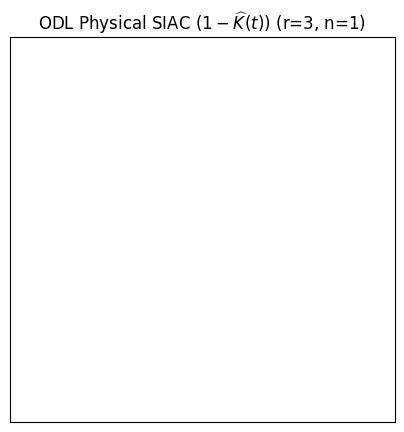

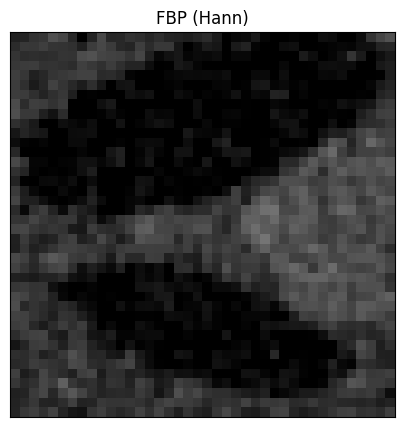

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'FBP (Hann)'}>)

In [9]:
from src.siac_modal import centered_cardinal_bspline, siac_cgam


def siac_spline_filter(moments, BSorder):
    cgam = siac_cgam(moments, BSorder)
    R = len(cgam) - 1
    gammas = np.arange(-R, R + 1)       # shifts
    B = centered_cardinal_bspline(BSorder)
    
    def kernel(x):
        x = np.asarray(x, dtype=float)
        out = np.zeros_like(x, dtype=float)
        for c, xg in zip(cgam, gammas):
            out += c * B(x - xg)
        return out
    
    def filt(t):
        t = np.asarray(t, dtype=float)
        t = np.clip(t, 0.0, 1.0)
        
        W = kernel(t)
        return 1 - W
    return filt
            
# SIAC Parameters
moments = 2
BSorder = 1

# Pass costom filter to ODL and fetch FBP operator
fbp_siac_op = odl.tomo.fbp_op(
    A,
    filter_type=siac_spline_filter(moments=moments, BSorder=BSorder),
    padding=True,
    frequency_scaling=1.0
)
fbp_siac_odl = fbp_siac_op(sino_noisy)
fbp_siac = fbp_siac_odl.asarray()

plot_img(img=fbp_ramp, title=f"FBP (ramp)")
plot_img(img=fbp_siac, title=f"ODL Physical SIAC ($1-\widehat K(t)$) (r={moments+1}, n={BSorder})")
plot_img(img=fbp_hann, title="FBP (Hann)")

plot_img_zoom(img=fbp_ramp, title=f"FBP (ramp)")
plot_img_zoom(img=fbp_siac, title=f"ODL Physical SIAC ($1-\widehat K(t)$) (r={moments+1}, n={BSorder})")
plot_img_zoom(img=fbp_hann, title="FBP (Hann)")